In [1]:
from unet1 import UNet
from testing_model import LightningModel
from helper_functions import *
from testing_functions import *
from torchmetrics.image import StructuralSimilarityIndexMeasure
import csv
ssim = StructuralSimilarityIndexMeasure(data_range=1.0)

In [2]:
mice = ['../../Datasets/optoacousticsparse/mice_sparse16_recon_256.mat', '../../Datasets/optoacousticsparse/mice_sparse32_recon_256.mat', '../../Datasets/optoacousticsparse/mice_full_recon_256.mat']
v_phantom = ['../../Datasets/optoacousticsparse/v_phantom_sparse16_recon_256.mat', '../../Datasets/optoacousticsparse/v_phantom_sparse32_recon_256.mat', '../../Datasets/optoacousticsparse/v_phantom_full_recon_256.mat']
phantom = ['../../Datasets/optoacousticsparse/phantom_sparse16_recon_256.mat', '../../Datasets/optoacousticsparse/phantom_sparse32_recon_256.mat', '../../Datasets/optoacousticsparse/phantom_full_recon_256.mat']


In [4]:
model_pth_mouse='../final_model_weight/PAOmniNet/PA_OmniNet_Generalized.pth'
model_pth_mouse32=('../final_model_weight/Mice/PA_OmniNet_mouse_32.pth')
model_pth_mouse16=('../final_model_weight/Mice/PA_OmniNet_mouse_16.pth')

model_pth_phantom32=('../final_model_weight/Mice/PA_OmniNet_phantom_32.pth')
model_pth_phantom16=('../final_model_weight/Mice/PA_OmniNet_phantom_16.pth')

model_pth_v_phantom32=('../final_model_weight/Mice/PA_OmniNet_v_phantom_32.pth')
model_pth_v_phantom16=('../final_model_weight/Mice/PA_OmniNet_v_phantom_16.pth')
hparams = {
    "batch_size": 32,
    "learning_rate": 1e-4,
    "nb_levels": 4,
    "nb_inner_channels": 32,
    "nb_conv_layers_per_stage": 2,
    "data_slice_only": True,
    "max_epochs": 250,
}
model = LightningModel(hparams)
state_dict = torch.load(model_pth_mouse, map_location=torch.device('cpu'))
model.load_state_dict(state_dict)

NeuralizerMouse32 = LightningModel(hparams)
state_dict = torch.load(model_pth_mouse32, map_location=torch.device('cpu'))
NeuralizerMouse32.load_state_dict(state_dict)

NeuralizerMouse16 = LightningModel(hparams)
state_dict = torch.load(model_pth_mouse16, map_location=torch.device('cpu'))
NeuralizerMouse16.load_state_dict(state_dict)

NeuralizerPhantom32 = LightningModel(hparams)
state_dict = torch.load(model_pth_phantom32, map_location=torch.device('cpu'))
NeuralizerPhantom32.load_state_dict(state_dict)

NeuralizerPhantom16 = LightningModel(hparams)
state_dict = torch.load(model_pth_phantom16, map_location=torch.device('cpu'))
NeuralizerPhantom16.load_state_dict(state_dict)

Neuralizer_v_Phantom32 = LightningModel(hparams)
state_dict = torch.load(model_pth_v_phantom32, map_location=torch.device('cpu'))
Neuralizer_v_Phantom32.load_state_dict(state_dict)

Neuralizer_v_Phantom16 = LightningModel(hparams)
state_dict = torch.load(model_pth_v_phantom16, map_location=torch.device('cpu'))
Neuralizer_v_Phantom16.load_state_dict(state_dict)


Unet_mouse16_path = '../final_model_weight/Mice/Unet_mouse16.pth'
Unet_mouse16 = UNet()
Unet_mouse16.load_state_dict(torch.load(Unet_mouse16_path, map_location=torch.device('cpu')))
Unet_mouse16.eval()  

Unet_mouse32_path = '../final_model_weight/Mice/Unet_mouse32.pth'
Unet_mouse32 = UNet()
Unet_mouse32.load_state_dict(torch.load(Unet_mouse32_path, map_location=torch.device('cpu')))
Unet_mouse32.eval()   

Unet_phantom16_path = '../final_model_weight/Mice/Unet_phantom16.pth'
Unet_phantom16 = UNet()
Unet_phantom16.load_state_dict(torch.load(Unet_phantom16_path, map_location=torch.device('cpu')))
Unet_phantom16.eval()  

Unet_phantom32_path = '../final_model_weight/Mice/Unet_phantom32.pth'
Unet_phantom32 = UNet()
Unet_phantom32.load_state_dict(torch.load(Unet_phantom32_path, map_location=torch.device('cpu')))
Unet_phantom32.eval()  

Unet_vphantom16_path = '../final_model_weight/Mice/Unet_vphantom16.pth'
Unet_vphantom16 = UNet()
Unet_vphantom16.load_state_dict(torch.load(Unet_vphantom16_path, map_location=torch.device('cpu')))
Unet_vphantom16.eval()  

Unet_vphantom32_path = '../final_model_weight/Mice/Unet_vphantom32.pth'
Unet_vphantom32 = UNet()
Unet_vphantom32.load_state_dict(torch.load(Unet_vphantom32_path, map_location=torch.device('cpu')))
Unet_vphantom32.eval()  

UnetSWFDSemi = '../final_model_weight/Unet/Unet_Generalized.pth'
Unet_Semi_model = UNet()
Unet_Semi_model.load_state_dict(torch.load(UnetSWFDSemi, map_location=torch.device('cpu')))
Unet_Semi_model.eval()  

print('Loaded')

C:\Users\olivi\AppData\Local\Temp\ipykernel_348136\3748453204.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_pth_mouse, map_location=torc

Loaded


C:\Users\olivi\AppData\Local\Temp\ipykernel_348136\3748453204.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Unet_phantom32.load_state_dict(torch.load(Unet_phantom32_p

In [5]:
def preprocess_Unet(image, size=(256, 256)):
    image = (image - image.min()) / (image.max() - image.min())
    image = torch.tensor(image)
    image = image.unsqueeze(0)
    return image

def preprocess_batch_Unet(images, size=(256, 256)):
    processed_images = []
    for image in images:
        processed_image = preprocess_Unet(image, size)
        processed_images.append(processed_image)
    return torch.cat(processed_images, dim=0)

def data_loader_formatter(in_filepath, out_filepath):
    with h5py.File(in_filepath, 'r') as infile:
        first_key = list(infile.keys())[0]
        data_in = infile[first_key][()]

    with h5py.File(out_filepath, 'r') as outfile:
        first_key = list(outfile.keys())[0]
        data_out = outfile[first_key][()]

    return data_in, data_out

In [6]:
def preprocess_mat_Neuralizer(image, size=(256, 256)):
    image = (image - image.min()) / (image.max() - image.min())
    image = cv2.resize(image, size, interpolation=cv2.INTER_LINEAR)
    image = np.stack([image] * 3, axis=-1)
    image = torch.tensor(image)
    image = image.unsqueeze(0)
    image = image.permute(0, 3, 1, 2).float()
    return image


def data_loader_formatter_Neuralizer(in_filepath, out_filepath):
    with h5py.File(in_filepath, 'r') as infile:
        first_key = list(infile.keys())[0]
        data_in = infile[first_key][()]

    with h5py.File(out_filepath, 'r') as outfile:
        first_key = list(outfile.keys())[0]
        data_out = outfile[first_key][()]

    return data_in, data_out

def preprocess_batch_Neuralizer(images, size=(256, 256)):
    processed_images = []
    for image in images:
        processed_image = preprocess_mat_Neuralizer(image, size)
        processed_images.append(processed_image)
    return torch.cat(processed_images, dim=0)

In [7]:
CONTEXT_SIZE = 16
data_in = mice[0]
data_out = mice[2]

X, y = data_loader_formatter_Neuralizer(data_in,data_out)
size = X.shape[0]
indices = np.arange(size)
train_end = int(0.7 * size)
val_end = train_end + int(0.2 * size)

train_indices = indices[:train_end]
test_indices = indices[val_end:]

X_train, y_train = X[train_indices], y[train_indices]
X_test, y_test = X[test_indices], y[test_indices]



X_train_Neur = preprocess_batch_Neuralizer(X_train)
y_train_Neur = preprocess_batch_Neuralizer(y_train)
X_train_Unet = preprocess_batch_Unet(X_train)
y_train_Unet = preprocess_batch_Unet(y_train)


X_test_Unet = preprocess_batch_Unet(X_test)
y_test_Unet = preprocess_batch_Unet(y_test)
X_context = X_train_Neur[:CONTEXT_SIZE]
y_context = y_train_Neur[:CONTEXT_SIZE]

X_test_Neur = preprocess_batch_Neuralizer(X_test)
y_test_Neur = preprocess_batch_Neuralizer(y_test)

print("Train set:", X_train_Neur.shape, X_train_Unet.shape)
print("Test set:", X_test_Neur.shape, X_test_Unet.shape)
print("Context samples:", X_context.shape, y_context.shape)

Train set: torch.Size([191, 3, 256, 256]) torch.Size([191, 256, 256])
Test set: torch.Size([29, 3, 256, 256]) torch.Size([29, 256, 256])
Context samples: torch.Size([16, 3, 256, 256]) torch.Size([16, 3, 256, 256])


Iteration 0:


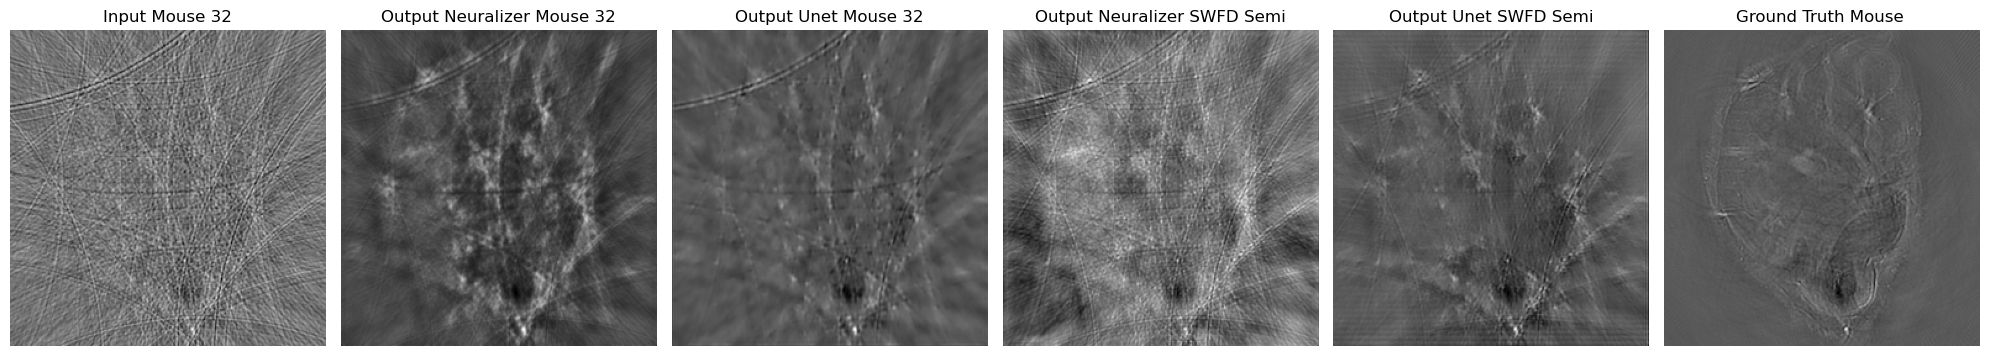

KeyboardInterrupt: 

In [8]:
import os
import matplotlib.pyplot as plt

specific_name = 'Mouse 32'
specific_model_unet = Unet_mouse32
specific_model_neuralizer = NeuralizerMouse32

main_dir = specific_name
os.makedirs(main_dir, exist_ok=True)

# Create subdirectories
subdirs = ['input', 'Generalized U-net', 'Specific U-net', 'Generalized PA OmniNet', 'Specific PA OmniNet', 'Ground Truth']
for subdir in subdirs:
    os.makedirs(os.path.join(main_dir, subdir), exist_ok=True)

for i in range(len(X_test)):
    input_Unet = X_test_Unet[i]
    input_Unet = input_Unet.float()
    input_Unet = input_Unet.unsqueeze(0)
    input_Unet = input_Unet.unsqueeze(0)
    input_Neur = X_test_Neur[i]

    ground_truth_Unet = y_test_Unet[i]
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Neur = y_test_Neur[i]

    output_Neur = model.forward(input_Neur.unsqueeze(0), X_context.unsqueeze(0), y_context.unsqueeze(0))
    output_Neur_specific = specific_model_neuralizer.forward(input_Neur.unsqueeze(0), X_context.unsqueeze(0), y_context.unsqueeze(0))
    output_Unet_Semi = Unet_Semi_model(input_Unet)
    output_Unet_Specific = specific_model_unet(input_Unet)

    normalized_output_Neur = (output_Neur - output_Neur.min()) / (output_Neur.max() - output_Neur.min())
    normalized_output_Semi = (output_Unet_Semi - output_Unet_Semi.min()) / (output_Unet_Semi.max() - output_Unet_Semi.min())
    normalized_output_Neur_specific = (output_Neur_specific - output_Neur_specific.min()) / (output_Neur_specific.max() - output_Neur_specific.min())
    normalized_output_Specific = (output_Unet_Specific - output_Unet_Specific.min()) / (output_Unet_Specific.max() - output_Unet_Specific.min())

    # Convert outputs to numpy arrays and squeeze extra dimensions
    normalized_output_Neur_img = normalized_output_Neur.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    normalized_output_Neur_img_specific = normalized_output_Neur_specific.squeeze().permute(1, 2, 0).cpu().detach().numpy()
    normalized_output_Semi_img = normalized_output_Semi.squeeze().cpu().detach().numpy()
    normalized_output_Specific_img = normalized_output_Specific.squeeze().cpu().detach().numpy()
    ground_truth_img = ground_truth_Unet.squeeze().cpu().numpy()
    input_img = X_test[i].squeeze()
    # print(normalized_output_Neur_img_specific.shape)
    # Debug: Print shapes of images
    print(f"Iteration {i}:")
    # print(f"Input: {input_img.shape}")
    # print(f"Neuralizer: {normalized_output_Neur_img.shape}")
    # print(f"Neuralizer Specific: {normalized_output_Neur_img_specific.shape}")
    # print(f"Unet Semi: {normalized_output_Semi_img.shape}")
    # print(f"Unet Specific: {normalized_output_Specific_img.shape}")
    # print(f"Ground Truth: {ground_truth_img.shape}")

    # Ensure all images are 2D (grayscale)
    if len(input_img.shape) > 2:
        input_img = input_img.mean(axis=-1)  # Convert to grayscale by averaging channels
    if len(normalized_output_Neur_img.shape) > 2:
        normalized_output_Neur_img = normalized_output_Neur_img.mean(axis=-1)
    if len(normalized_output_Neur_img_specific.shape) > 2:
        normalized_output_Neur_img_specific = normalized_output_Neur_img_specific.mean(axis=-1)
    if len(normalized_output_Semi_img.shape) > 2:
        normalized_output_Semi_img = normalized_output_Semi_img.mean(axis=-1)
    if len(normalized_output_Specific_img.shape) > 2:
        normalized_output_Specific_img = normalized_output_Specific_img.mean(axis=-1)
    if len(ground_truth_img.shape) > 2:
        ground_truth_img = ground_truth_img.mean(axis=-1)

    plt.imsave(os.path.join(main_dir, 'input', f'input_{i}.png'), input_img, cmap='gray')
    plt.imsave(os.path.join(main_dir, 'Generalized U-net', f'generalized_unet_{i}.png'), normalized_output_Semi_img, cmap='gray')
    plt.imsave(os.path.join(main_dir, 'Specific U-net', f'specific_unet_{i}.png'), normalized_output_Specific_img, cmap='gray')
    plt.imsave(os.path.join(main_dir, 'Generalized PA OmniNet', f'generalized_pa_omninet_{i}.png'), normalized_output_Neur_img, cmap='gray')
    plt.imsave(os.path.join(main_dir, 'Specific PA OmniNet', f'specific_pa_omninet_{i}.png'), normalized_output_Neur_img_specific, cmap='gray')
    plt.imsave(os.path.join(main_dir, 'Ground Truth', f'ground_truth_{i}.png'), ground_truth_img, cmap='gray')

    # Visualization (optional)
    titles = [f'Input {specific_name}', f'Output Neuralizer {specific_name}',
              f'Output Unet {specific_name}','Output Neuralizer SWFD Semi', 'Output Unet SWFD Semi', f'Ground Truth {specific_name[:-2]}']
    images = [input_img, normalized_output_Neur_img_specific, normalized_output_Specific_img, normalized_output_Neur_img, normalized_output_Semi_img, ground_truth_img]

    plt.figure(figsize=(20, 5))
    for idx, (title, img) in enumerate(zip(titles, images)):
        plt.subplot(1, 6, idx + 1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()




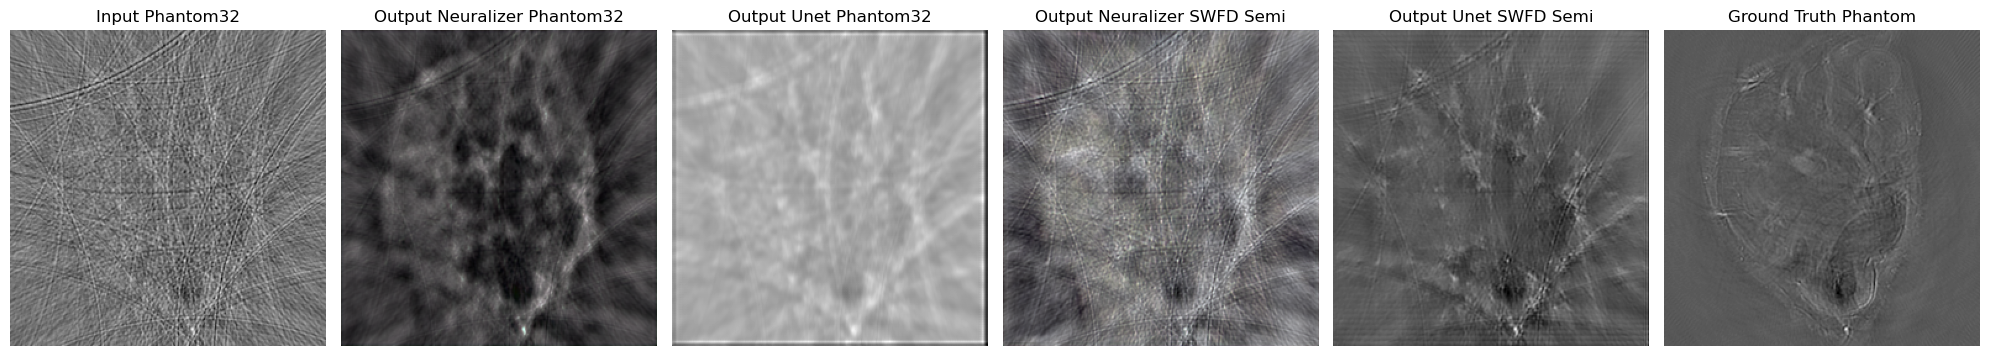

0
Base: SSIM 0.5282940864562988, RMSE: 0.13754836824805394, PSNR: 17.230891006984777
Neuralizer Specific: SSIM 0.4578155279159546, RMSE: 0.13397370426626615, PSNR: 17.459608777401197
Neuralizer: SSIM 0.4501541256904602, RMSE: 0.13095402497233902, PSNR: 17.657622852560724
Unet Semi: SSIM 0.6686521768569946, RMSE: 0.05397778195159885, PSNR: 25.35569930776958
Unet Specific: SSIM 0.6693764328956604, RMSE: 0.3205141209941656, PSNR: 9.883056637427543


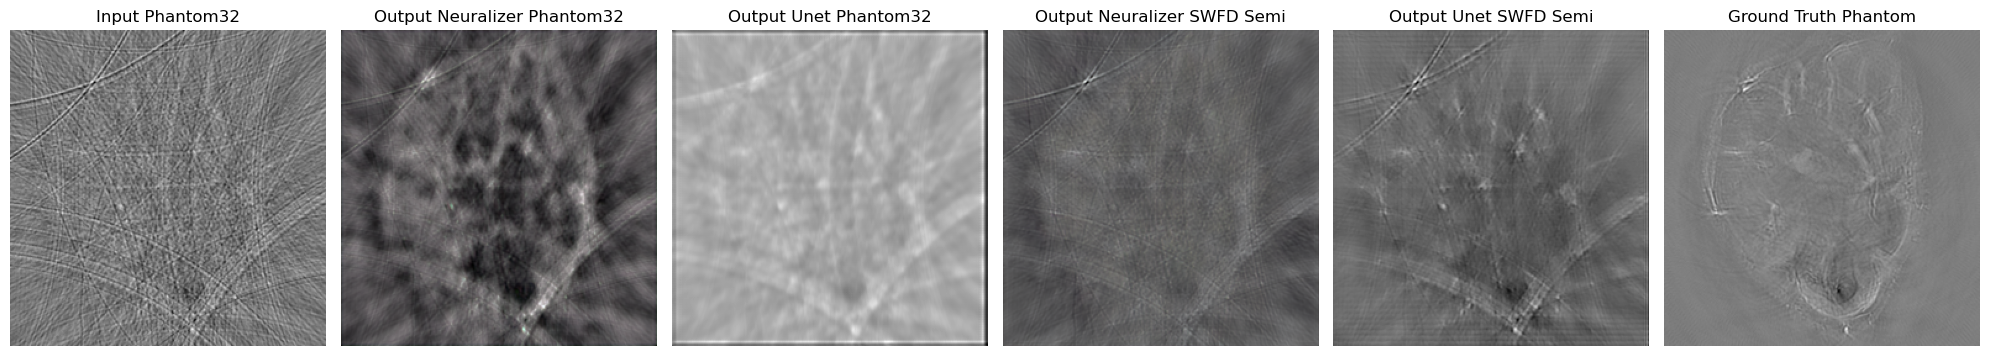

1
Base: SSIM 0.5448472499847412, RMSE: 0.0806573903139168, PSNR: 21.867116658934602
Neuralizer Specific: SSIM 0.3844005763530731, RMSE: 0.18414563565078704, PSNR: 14.6967712408381
Neuralizer: SSIM 0.7072802186012268, RMSE: 0.13074299633413045, PSNR: 17.671631517188487
Unet Semi: SSIM 0.7077898979187012, RMSE: 0.10075694934893126, PSNR: 19.934499805015232
Unet Specific: SSIM 0.6873666048049927, RMSE: 0.17925673974771544, PSNR: 14.93049013242603


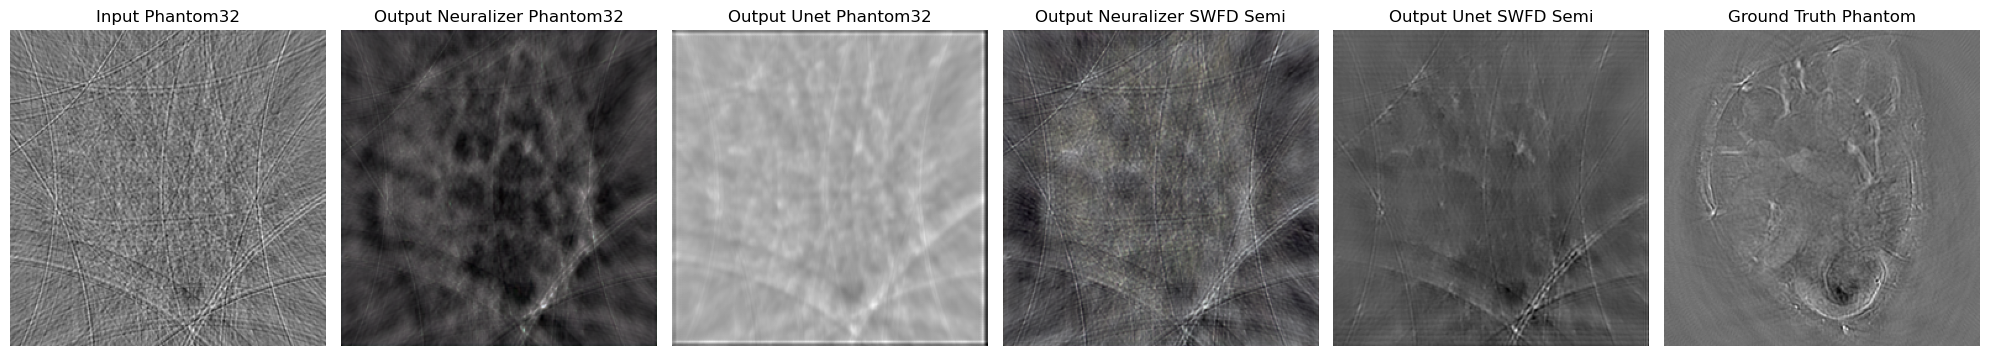

2
Base: SSIM 0.5297925472259521, RMSE: 0.09406660680106742, PSNR: 20.531290326201596
Neuralizer Specific: SSIM 0.5039511322975159, RMSE: 0.21721086410709467, PSNR: 13.262369115616057
Neuralizer: SSIM 0.5083631873130798, RMSE: 0.12267443892593766, PSNR: 18.22491805991111
Unet Semi: SSIM 0.6857839226722717, RMSE: 0.12034007188306255, PSNR: 18.391794668519623
Unet Specific: SSIM 0.6560766696929932, RMSE: 0.23730430961617063, PSNR: 12.493887492245994


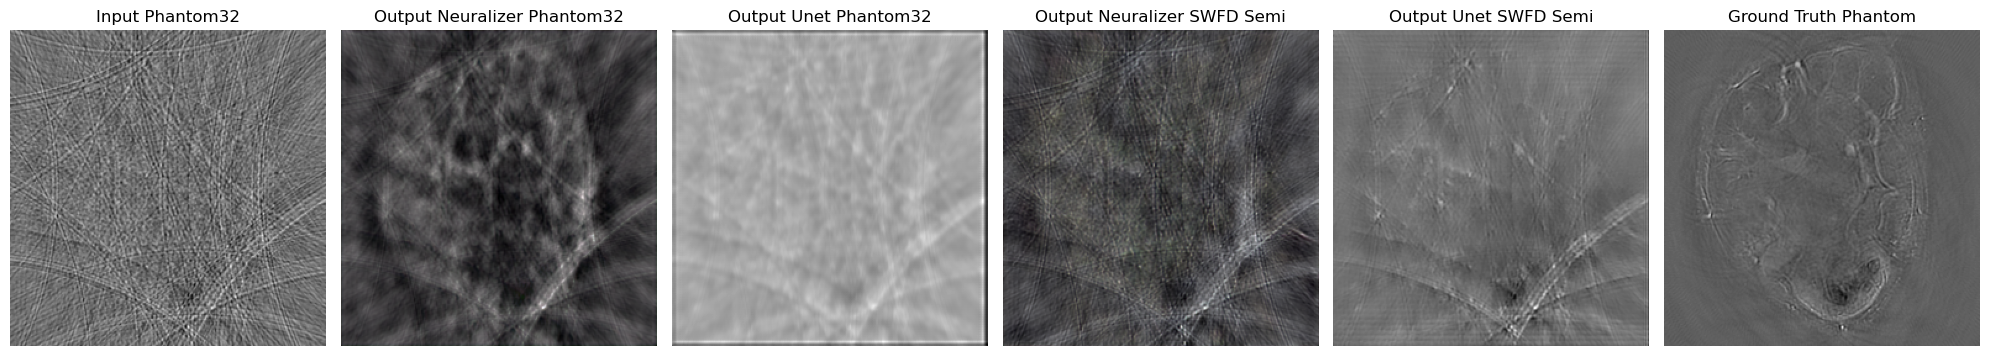

3
Base: SSIM 0.5313530564308167, RMSE: 0.11201401702332281, PSNR: 19.014552417000072
Neuralizer Specific: SSIM 0.42401179671287537, RMSE: 0.1404614225668074, PSNR: 17.048859188341435
Neuralizer: SSIM 0.5374139547348022, RMSE: 0.10721478006634336, PSNR: 19.394906719617616
Unet Semi: SSIM 0.7041996717453003, RMSE: 0.0807547383380411, PSNR: 21.856639714626706
Unet Specific: SSIM 0.6836097836494446, RMSE: 0.28320031867082385, PSNR: 10.958125245852825


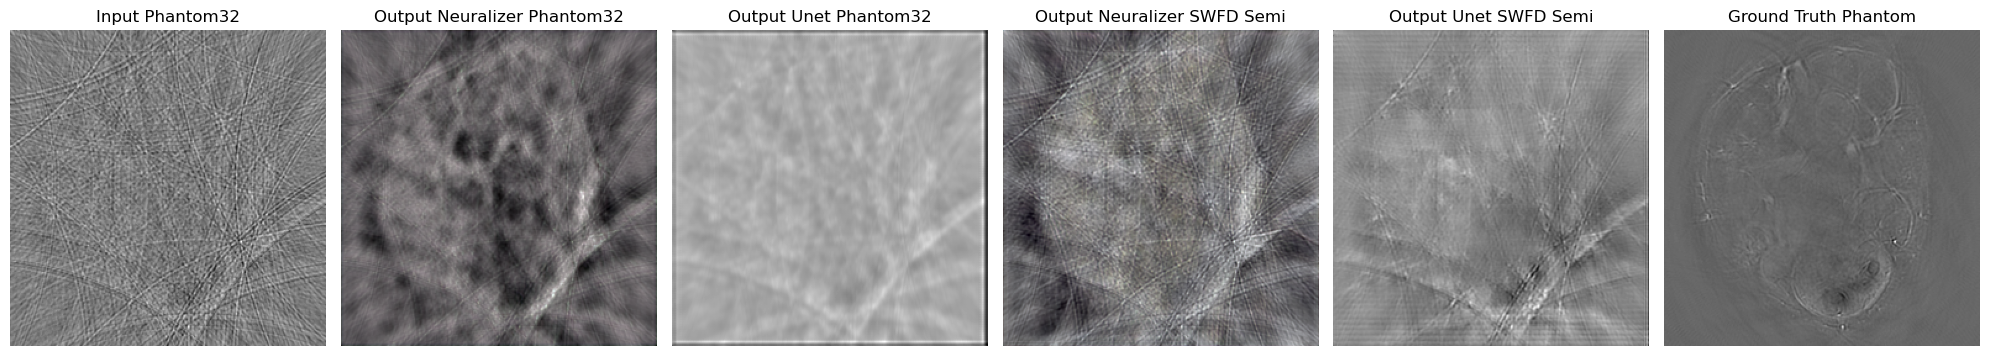

4
Base: SSIM 0.5444756746292114, RMSE: 0.1191691575513895, PSNR: 18.476722381222025
Neuralizer Specific: SSIM 0.3694876730442047, RMSE: 0.08751076893869318, PSNR: 21.158769990376136
Neuralizer: SSIM 0.3849070370197296, RMSE: 0.11196794610768973, PSNR: 19.01812583411222
Unet Semi: SSIM 0.6057800650596619, RMSE: 0.1475674368048723, PSNR: 16.62018932399629
Unet Specific: SSIM 0.7032222151756287, RMSE: 0.2661761711893064, PSNR: 11.496616526753805


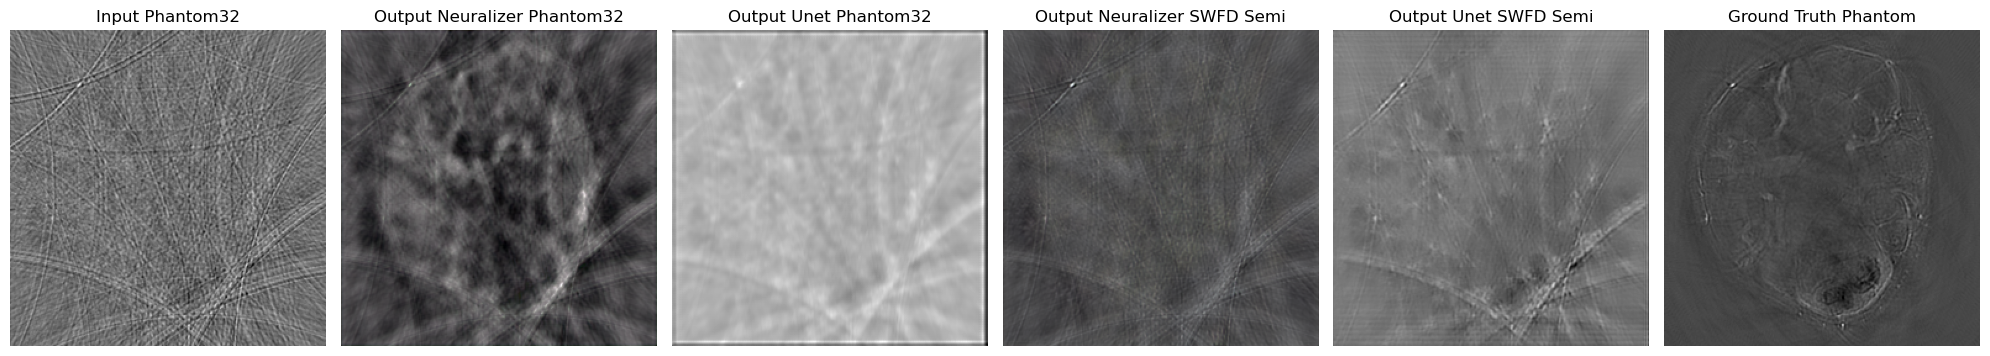

5
Base: SSIM 0.5435384511947632, RMSE: 0.1840267452524917, PSNR: 14.702381273130165
Neuralizer Specific: SSIM 0.407642126083374, RMSE: 0.08047803309050273, PSNR: 21.88645274343743
Neuralizer: SSIM 0.7041532397270203, RMSE: 0.057774077596336085, PSNR: 24.765339066599207
Unet Semi: SSIM 0.6993443965911865, RMSE: 0.1820020696350418, PSNR: 14.798473468214144
Unet Specific: SSIM 0.6735166311264038, RMSE: 0.4211229987207733, PSNR: 7.511820797584949


KeyboardInterrupt: 

In [19]:

csv_baseline = 'Baseline_mouse32_alt.csv'
csv_neur = 'PAOmniNet_Generalized_mouse32_alt.csv'
csv_neur_specific = 'PAOmniNet_Specific_mouse32_alt.csv'
specific_name = 'Phantom32'
csv_unet_semi = 'Unet_Generalized_mouse32_alt.csv'
csv_unet_specific = 'Unet_Specific_mouse32_alt.csv'
specific_model_unet = Unet_mouse16
specific_model_neuralizer = NeuralizerMouse16
# # #
# with open(csv_baseline, mode="a", newline="") as csv_baseline_file:
#     writer = csv.writer(csv_baseline_file)
#     writer.writerow(["Index", "SSIM", "RMSE", "PSNR"])
# with open(csv_neur, mode="a", newline="") as neuralizer_file:
#     writer = csv.writer(neuralizer_file)
#     writer.writerow(["Index", "SSIM", "RMSE", "PSNR"])
# with open(csv_neur_specific, mode="a", newline="") as neuralizer_specific_file:
#     writer = csv.writer(neuralizer_specific_file)
#     writer.writerow(["Index", "SSIM", "RMSE", "PSNR"])
#
# with open(csv_unet_specific, mode="a", newline="") as Unet_specific_file:
#     writer = csv.writer(Unet_specific_file)
#     writer.writerow(["Index", "SSIM", "RMSE", "PSNR"])
# #
# with open(csv_unet_semi, mode="a", newline="") as Unet_Semi_file:
#     writer = csv.writer(Unet_Semi_file)
#     writer.writerow(["Index", "SSIM", "RMSE", "PSNR"])
#
for i in range(len(X_test)):
    input_Unet = X_test_Unet[i]
    input_Unet = input_Unet.float()
    input_Unet = input_Unet.unsqueeze(0)
    input_Unet = input_Unet.unsqueeze(0)
    input_Neur = X_test_Neur[i]

    ground_truth_Unet = y_test_Unet[i]
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
    ground_truth_Neur = y_test_Neur[i]

    output_Neur = model.forward(input_Neur.unsqueeze(0), X_context.unsqueeze(0), y_context.unsqueeze(0))
    output_Neur_specific = specific_model_neuralizer.forward(input_Neur.unsqueeze(0), X_context.unsqueeze(0), y_context.unsqueeze(0))
    output_Unet_Semi = Unet_Semi_model(input_Unet)
    output_Unet_Specific = specific_model_unet(input_Unet)

    normalized_output_Neur = (output_Neur - output_Neur.min()) / (output_Neur.max() - output_Neur.min())
    normalized_output_Semi = (output_Unet_Semi - output_Unet_Semi.min()) / (output_Unet_Semi.max() - output_Unet_Semi.min())
    normalized_output_Neur_specific = (output_Neur_specific - output_Neur_specific.min()) / (output_Neur_specific.max() - output_Neur_specific.min())
    normalized_output_Specific = (output_Unet_Specific - output_Unet_Specific.min()) / (output_Unet_Specific.max() - output_Unet_Specific.min())

    rmse_val_base = compute_rmse(ground_truth_Neur, input_Neur)
    psnr_val_base = compute_psnr(ground_truth_Neur, input_Neur)
    ssim_val_base = ssim(ground_truth_Neur.unsqueeze(0), input_Neur.unsqueeze(0)).item()

    rmse_val_neur = compute_rmse(ground_truth_Neur, normalized_output_Neur.squeeze(0))
    psnr_val_neur = compute_psnr(ground_truth_Neur, normalized_output_Neur.squeeze(0))
    ssim_val_neur = ssim(ground_truth_Neur.unsqueeze(0), normalized_output_Neur).item()

    rmse_val_neur_specific = compute_rmse(ground_truth_Neur, normalized_output_Neur_specific.squeeze(0))
    psnr_val_neur_specific = compute_psnr(ground_truth_Neur, normalized_output_Neur_specific.squeeze(0))
    ssim_val_neur_specific = ssim(ground_truth_Neur.unsqueeze(0), normalized_output_Neur_specific).item()

    rmse_semi = compute_rmse(ground_truth_Unet, normalized_output_Semi)
    psnr_semi = compute_psnr(ground_truth_Unet, normalized_output_Semi)
    ssim_semi = ssim(ground_truth_Unet, normalized_output_Semi).item()

    rmse_specific = compute_rmse(ground_truth_Unet, normalized_output_Specific)
    psnr_specific = compute_psnr(ground_truth_Unet, normalized_output_Specific)
    ssim_specific = ssim(ground_truth_Unet, normalized_output_Specific).item()

    normalized_output_Neur_img = normalized_output_Neur.squeeze().permute(1,2,0).cpu().detach().numpy()
    normalized_output_Neur_img_specific = normalized_output_Neur_specific.squeeze().permute(1,2,0).cpu().detach().numpy()
    normalized_output_Semi_img = normalized_output_Semi.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    normalized_output_Specific_img = normalized_output_Specific.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    ground_truth_img = ground_truth_Unet.squeeze().cpu().numpy()

    # Visualization
    titles = [f'Input {specific_name}', f'Output Neuralizer {specific_name}',
              f'Output Unet {specific_name}','Output Neuralizer SWFD Semi', 'Output Unet SWFD Semi', f'Ground Truth {specific_name[:-2]}']
    images = [X_test[i], normalized_output_Neur_img_specific, normalized_output_Specific_img, normalized_output_Neur_img, normalized_output_Semi_img, y_test[i]]

    plt.figure(figsize=(20, 5))
    for idx, (title, img) in enumerate(zip(titles, images)):
        plt.subplot(1, 6, idx + 1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    print(i)
    print(f'Base: SSIM {ssim_val_base}, RMSE: {rmse_val_base}, PSNR: {psnr_val_base}')
    print(f'Neuralizer Specific: SSIM {ssim_val_neur_specific}, RMSE: {rmse_val_neur_specific}, PSNR: {psnr_val_neur_specific}')
    print(f'Neuralizer: SSIM {ssim_val_neur}, RMSE: {rmse_val_neur}, PSNR: {psnr_val_neur}')
    print(f'Unet Semi: SSIM {ssim_semi}, RMSE: {rmse_semi}, PSNR: {psnr_semi}')
    print(f'Unet Specific: SSIM {ssim_specific}, RMSE: {rmse_specific}, PSNR: {psnr_specific}')
    #
    # with open(csv_neur, mode="a", newline="") as neuralizer_file:
    #     writer = csv.writer(neuralizer_file)
    #     writer.writerow([i, ssim_val_neur, rmse_val_neur, psnr_val_neur])
    #
    # with open(csv_baseline, mode="a", newline="") as csv_baseline_file:
    #     writer = csv.writer(csv_baseline_file)
    #     writer.writerow([i, ssim_val_base, rmse_val_base, psnr_val_base])
    #
    # with open(csv_neur_specific, mode="a", newline="") as neuralizer_specific_file:
    #     writer = csv.writer(neuralizer_specific_file)
    #     writer.writerow([i, ssim_val_neur_specific, rmse_val_neur_specific, psnr_val_neur_specific])
    #
    # with open(csv_unet_specific, mode="a", newline="") as Unet_specific_file:
    #     writer = csv.writer(Unet_specific_file)
    #     writer.writerow([i, ssim_specific, rmse_specific, psnr_specific])
    #
    # with open(csv_unet_semi, mode="a", newline="") as Unet_Semi_file:
    #     writer = csv.writer(Unet_Semi_file)
    #     writer.writerow([i, ssim_semi, rmse_semi, psnr_semi])

In [ ]:
ssim_gen_total_collection = []
rmse_gen_total_collection = []
psnr_gen_total_collection = []

ssim_sp_total_collection = []
rmse_sp_total_collection = []
psnr_sp_total_collection = []
for j in range(32):
    print(f'starting with context size {j}')
    # csv_baseline = 'Baseline_phantom32.csv'
    csv_neur = f'PAOmniNet_Generalized_vphantom16_context{j+1}.csv'
    csv_neur_specific = f'PAOmniNet_Specific_vphantom16_context{j+1}.csv'
    specific_name = f'Vphatnom 16 {j}'
    # csv_unet_semi = 'Unet_Generalized_phantom32.csv'
    # csv_unet_specific = 'Unet_Specific_phantom32.csv'
    specific_model_unet = Unet_vphantom16
    specific_model_neuralizer = Neuralizer_v_Phantom16
# # #
    CONTEXT_SIZE = j+1
    data_in = v_phantom[0]
    data_out = v_phantom[2]

    X, y = data_loader_formatter_Neuralizer(data_in,data_out)
    size = X.shape[0]
    indices = np.arange(size)
    train_end = int(0.7 * size)
    val_end = train_end + int(0.2 * size)

    train_indices = indices[:train_end]
    test_indices = indices[val_end:]

    X_train, y_train = X[train_indices], y[train_indices]
    X_test, y_test = X[test_indices], y[test_indices]



    X_train_Neur = preprocess_batch_Neuralizer(X_train)
    y_train_Neur = preprocess_batch_Neuralizer(y_train)
    X_context = X_train_Neur[:CONTEXT_SIZE]
    y_context = y_train_Neur[:CONTEXT_SIZE]

    X_test_Neur = preprocess_batch_Neuralizer(X_test)
    y_test_Neur = preprocess_batch_Neuralizer(y_test)

    print("Train set:", X_train_Neur.shape)
    print("Test set:", X_test_Neur.shape)
    print("Context samples:", X_context.shape, y_context.shape)

    with open(csv_neur, mode="a", newline="") as neuralizer_file:
        writer = csv.writer(neuralizer_file)
        writer.writerow(["Index", "SSIM", "RMSE", "PSNR"])
    with open(csv_neur_specific, mode="a", newline="") as neuralizer_specific_file:
        writer = csv.writer(neuralizer_specific_file)
        writer.writerow(["Index", "SSIM", "RMSE", "PSNR"])
    #

    #
    ssim_gen_total = 0
    rmse_gen_total = 0
    psnr_gen_total= 0

    ssim_sp_total = 0
    rmse_sp_total = 0
    psnr_sp_total= 0
    for i in range(len(X_test)):
        input_Neur = X_test_Neur[i]

        ground_truth_Unet = y_test_Unet[i]
        ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
        ground_truth_Unet = ground_truth_Unet.unsqueeze(0)
        ground_truth_Neur = y_test_Neur[i]

        output_Neur = model.forward(input_Neur.unsqueeze(0), X_context.unsqueeze(0), y_context.unsqueeze(0))
        output_Neur_specific = specific_model_neuralizer.forward(input_Neur.unsqueeze(0), X_context.unsqueeze(0), y_context.unsqueeze(0))

        normalized_output_Neur = (output_Neur - output_Neur.min()) / (output_Neur.max() - output_Neur.min())
        normalized_output_Neur_specific = (output_Neur_specific - output_Neur_specific.min()) / (output_Neur_specific.max() - output_Neur_specific.min())


        rmse_val_neur = compute_rmse(ground_truth_Neur, normalized_output_Neur.squeeze(0))
        psnr_val_neur = compute_psnr(ground_truth_Neur, normalized_output_Neur.squeeze(0))
        ssim_val_neur = ssim(ground_truth_Neur.unsqueeze(0), normalized_output_Neur).item()
        ssim_gen_total += ssim_val_neur
        psnr_gen_total += psnr_val_neur
        rmse_gen_total += rmse_val_neur

        rmse_val_neur_specific = compute_rmse(ground_truth_Neur, normalized_output_Neur_specific.squeeze(0))
        psnr_val_neur_specific = compute_psnr(ground_truth_Neur, normalized_output_Neur_specific.squeeze(0))
        ssim_val_neur_specific = ssim(ground_truth_Neur.unsqueeze(0), normalized_output_Neur_specific).item()
        ssim_sp_total += ssim_val_neur_specific
        psnr_sp_total += psnr_val_neur_specific
        rmse_sp_total += rmse_val_neur_specific

        normalized_output_Neur_img = normalized_output_Neur.squeeze().permute(1,2,0).cpu().detach().numpy()
        normalized_output_Neur_img_specific = normalized_output_Neur_specific.squeeze().permute(1,2,0).cpu().detach().numpy()
        ground_truth_img = ground_truth_Unet.squeeze().cpu().numpy()
        with open(csv_neur, mode="a", newline="") as neuralizer_file:
            writer = csv.writer(neuralizer_file)
            writer.writerow([i, ssim_val_neur, rmse_val_neur, psnr_val_neur])

        with open(csv_neur_specific, mode="a", newline="") as neuralizer_specific_file:
            writer = csv.writer(neuralizer_specific_file)
            writer.writerow([i, ssim_val_neur_specific, rmse_val_neur_specific, psnr_val_neur_specific])
        if i == 0:
            titles = [ f'Output Neuralizer {specific_name}','Output Neuralizer SWFD Semi']
            images = [normalized_output_Neur_img_specific, normalized_output_Neur_img]

            plt.figure(figsize=(20, 5))
            for idx, (title, img) in enumerate(zip(titles, images)):
                plt.subplot(1, 2, idx + 1)
                plt.imshow(img, cmap='gray')
                plt.title(title)
                plt.axis('off')
            plt.tight_layout()
            plt.show()
            print(f'Neuralizer Specific: SSIM {ssim_val_neur_specific}, RMSE: {rmse_val_neur_specific}, PSNR: {psnr_val_neur_specific}')
            print(f'Neuralizer: SSIM {ssim_val_neur}, RMSE: {rmse_val_neur}, PSNR: {psnr_val_neur}')
    avg_ssim_sp = ssim_sp_total/len(X_test)
    avg_ssim_gen = ssim_gen_total / len(X_test)

    avg_rmse_sp = rmse_sp_total/len(X_test)
    avg_rmse_gen = rmse_gen_total / len(X_test)

    avg_psnr_sp = psnr_sp_total/len(X_test)
    avg_psnr_gen = psnr_gen_total / len(X_test)
    print(f'Total Generalized: SSIM {avg_ssim_gen}, RMSE: {avg_rmse_gen}, PSNR:{avg_psnr_gen}')
    print(f'Total Specific: SSIM {avg_ssim_sp}, RMSE: {avg_rmse_sp}, PSNR:{avg_psnr_sp}')
    ssim_gen_total_collection.append(avg_ssim_gen)
    rmse_gen_total_collection.append(avg_rmse_gen)
    psnr_gen_total_collection.append(avg_psnr_gen)

    ssim_sp_total_collection.append(avg_ssim_sp)
    rmse_sp_total_collection.append(avg_rmse_sp)
    psnr_sp_total_collection.append(avg_psnr_sp)

print('LISTS:')
print(f'{ssim_gen_total_collection}\n {rmse_gen_total_collection}\n {psnr_gen_total_collection}\n{ssim_sp_total_collection}\n{rmse_sp_total_collection}\n{psnr_sp_total_collection}')